In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv("/content/messy_supermarket_530_rows.csv")

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,Category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type
0,1141,1/5/2024,Imtiaz,ISLAMABAD,Chicken,Dairy,1kg,NaN,NaN,Online,member
1,1399,4/11/2024,IMTIAZ,ISLAMABAD,Oil,DAIRY,5,NaN,546.0,Online,Regular
2,1007,4/12/2024,IMTIAZ,ISLAMABAD,Oil,Bakery,NaN,785/kg,NaN,CARD,regular
3,1335,2/4/2024,IMTIAZ,Islamabad,Chicken,Fruits,1,848/kg,NaN,Cash,Regular
4,1323,6/14/2024,metro,Islamabad,Milk,fruits,1,NaN,1419.0,cash,Regular
...,...,...,...,...,...,...,...,...,...,...,...
525,1072,7/5/2024,IMTIAZ,Lahore,Rice,DAIRY,2kg,310/kg,2191.0,Card,Member
526,1107,4/2/2024,Alfatah,Karachi,Apple,DAIRY,2kg,834,1955.0,Online,Regular
527,1271,10/6/2024,IMTIAZ,Karachi,Rice,fruits,6,512,1481.0,Card,member
528,1436,5/6/2024,IMTIAZ,Lahore,Apple,Grains,6,NaN,NaN,cash,Regular


## Exploratory Data Analysis (EDA)

In [ ]:
df.head()

,Transaction_ID,Date,Store,City,Product,Category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type
0,1141,1/5/2024,Imtiaz,ISLAMABAD,Chicken,Dairy,1kg,NaN,NaN,Online,member
1,1399,4/11/2024,IMTIAZ,ISLAMABAD,Oil,DAIRY,5,NaN,546.0,Online,Regular
2,1007,4/12/2024,IMTIAZ,ISLAMABAD,Oil,Bakery,NaN,785/kg,NaN,CARD,regular
3,1335,2/4/2024,IMTIAZ,Islamabad,Chicken,Fruits,1,848/kg,NaN,Cash,Regular
4,1323,6/14/2024,metro,Islamabad,Milk,fruits,1,NaN,1419.0,cash,Regular


In [ ]:
df.dtypes

,0
Transaction_ID,int64
Date,object
Store,object
City,object
Product,object
Category,object
Quantity,object
Unit_Price,object
Total_Price,float64
Payment_Method,object


In [ ]:
df.shape

(530, 11)

In [ ]:
print("total rows:", df.shape[0])
print("total columns:", df.shape[1])

total rows: 530
total columns: 11


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Store,0
City,0
Product,0
Category,0
Quantity,182
Unit_Price,184
Total_Price,255
Payment_Method,0


In [ ]:
df.nunique()

,0
Transaction_ID,500
Date,281
Store,6
City,6
Product,8
Category,10
Quantity,15
Unit_Price,308
Total_Price,255
Payment_Method,5


In [ ]:
df.duplicated().sum()

np.int64(30)

In [ ]:
df.describe()

,Transaction_ID,Total_Price
count,530.000000,275.000000
mean,1252.373585,2548.523636
std,145.570529,1450.874373
min,1001.000000,107.000000
25%,1125.000000,1254.500000
50%,1253.500000,2450.000000
75%,1378.000000,3839.000000
max,1500.000000,4997.000000


In [ ]:
df.count()

,0
Transaction_ID,530
Date,530
Store,530
City,530
Product,530
Category,530
Quantity,348
Unit_Price,346
Total_Price,275
Payment_Method,530


**## Data Preprocessing**




In [ ]:
# remove duplicates values
df.duplicated().sum()

np.int64(30)

In [ ]:
df=df.drop_duplicates(keep= 'first')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(500, 11)

In [ ]:
df.columns

Index(['Transaction_ID', 'Date', 'Store', 'City', 'Product', 'Category',
       'Quantity', 'Unit_Price', 'Total_Price', 'Payment_Method',
       'Customer_Type'],
      dtype='object')

In [ ]:
df['Transaction_ID'].unique()

array([1141, 1399, 1007, 1335, 1323, 1083, 1226, 1497, 1357, 1102, 1011,
       1078, 1300, 1319, 1470, 1003, 1159, 1258, 1195, 1317, 1447, 1105,
       1149, 1336, 1181, 1091, 1196, 1228, 1074, 1056, 1378, 1347, 1031,
       1076, 1341, 1071, 1010, 1223, 1185, 1457, 1290, 1205, 1281, 1239,
       1302, 1133, 1080, 1462, 1168, 1477, 1090, 1366, 1269, 1448, 1186,
       1472, 1358, 1219, 1496, 1348, 1288, 1073, 1409, 1155, 1118, 1069,
       1298, 1064, 1403, 1210, 1077, 1183, 1034, 1079, 1085, 1001, 1012,
       1023, 1272, 1235, 1362, 1474, 1368, 1193, 1019, 1421, 1407, 1016,
       1238, 1040, 1485, 1047, 1094, 1173, 1435, 1463, 1342, 1432, 1132,
       1339, 1372, 1138, 1498, 1418, 1070, 1371, 1313, 1370, 1376, 1174,
       1332, 1411, 1125, 1156, 1440, 1363, 1150, 1369, 1087, 1312, 1349,
       1285, 1465, 1361, 1415, 1020, 1057, 1374, 1401, 1356, 1454, 1325,
       1026, 1439, 1043, 1354, 1154, 1178, 1297, 1127, 1438, 1032, 1114,
       1230, 1322, 1441, 1058, 1221, 1025, 1018, 12

In [ ]:
# Conversion of Multiple date formate like DD-MM-YY, MM,DD,YY ,Desh formate

df['Date'].unique()

array(['1/5/2024', '4/11/2024', '4/12/2024', '2/4/2024', '6/14/2024',
       '2/29/2024', '7/1/2024', '20-04-2024', '1/3/2024', '14-03-2024',
       '6/9/2024', '4/26/2024', '3/2/2024', '4/4/2024', '25-02-2024',
       '3/28/2024', '4/2/2024', '1/6/2024', '25/04/2024', '6/3/2024',
       '22/05/2024', '16/05/2024', '24/01/2024', '2/9/2024', '5/22/2024',
       '27-04-2024', '9/5/2024', '6/28/2024', '19/03/2024', '3/8/2024',
       '7/5/2024', '8/4/2024', '16-04-2024', '28-02-2024', '1/15/2024',
       '23/06/2024', '10/1/2024', '27/03/2024', '28-06-2024', '11/3/2024',
       '25-01-2024', '24-05-2024', '1/24/2024', '25-06-2024',
       '29-01-2024', '18/02/2024', '3/16/2024', '6/19/2024', '14-06-2024',
       '7/3/2024', '6/5/2024', '20/04/2024', '21-04-2024', '31-01-2024',
       '16-01-2024', '5/30/2024', '16/04/2024', '16-06-2024', '8/1/2024',
       '4/24/2024', '29-04-2024', '21-06-2024', '6/11/2024', '12/6/2024',
       '19-03-2024', '30-03-2024', '4/13/2024', '16-02-2024',
     

In [ ]:
pd.to_datetime(df['Date'], format="mixed")

,Date
0,2024-01-05
1,2024-04-11
2,2024-04-12
3,2024-02-04
4,2024-06-14
...,...
525,2024-07-05
526,2024-04-02
527,2024-10-06
528,2024-05-06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 529
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  500 non-null    int64  
 1   Date            500 non-null    object 
 2   Store           500 non-null    object 
 3   City            500 non-null    object 
 4   Product         500 non-null    object 
 5   Category        500 non-null    object 
 6   Quantity        327 non-null    object 
 7   Unit_Price      328 non-null    object 
 8   Total_Price     263 non-null    float64
 9   Payment_Method  500 non-null    object 
 10  Customer_Type   500 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 46.9+ KB


In [ ]:
pd.to_datetime(df['Date'], format="mixed")

,Date
0,2024-01-05
1,2024-04-11
2,2024-04-12
3,2024-02-04
4,2024-06-14
...,...
525,2024-07-05
526,2024-04-02
527,2024-10-06
528,2024-05-06


In [ ]:
df['Date']=pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [ ]:
df["Date"].isnull().sum()

np.int64(203)

In [ ]:
df["Date"] = df["Date"].fillna(method ='ffill')

In [ ]:
df['Date'].unique()

<DatetimeArray>
['2024-05-01 00:00:00', '2024-11-04 00:00:00', '2024-12-04 00:00:00',
 '2024-04-02 00:00:00', '2024-01-07 00:00:00', '2024-03-01 00:00:00',
 '2024-09-06 00:00:00', '2024-02-03 00:00:00', '2024-04-04 00:00:00',
 '2024-02-04 00:00:00',
 ...
 '2024-10-06 00:00:00', '2024-02-12 00:00:00', '2024-06-25 00:00:00',
 '2024-06-17 00:00:00', '2024-04-03 00:00:00', '2024-06-28 00:00:00',
 '2024-05-21 00:00:00', '2024-10-04 00:00:00', '2024-06-10 00:00:00',
 '2024-06-05 00:00:00']
Length: 153, dtype: datetime64[ns]

In [ ]:
df["Date"].isnull().sum()

np.int64(0)

In [ ]:
# Convert standardize case, fix spelling / formatting,

df['Store'].unique()

array(['Imtiaz', 'IMTIAZ', 'metro', 'Alfatah', 'Metro', 'Al-Fatah'],
      dtype=object)

In [ ]:
df['Store']= df["Store"].str.title()
df['Store']= df["Store"].replace({'Al-Fatah':'Alfatah'})


In [ ]:
df['Store'].unique()

array(['Imtiaz', 'Metro', 'Alfatah'], dtype=object)

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,Category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type
0,1141,2024-05-01,Imtiaz,ISLAMABAD,Chicken,Dairy,1kg,NaN,NaN,Online,member
1,1399,2024-11-04,Imtiaz,ISLAMABAD,Oil,DAIRY,5,NaN,546.0,Online,Regular
2,1007,2024-12-04,Imtiaz,ISLAMABAD,Oil,Bakery,NaN,785/kg,NaN,CARD,regular
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Fruits,1,848/kg,NaN,Cash,Regular
4,1323,2024-04-02,Metro,Islamabad,Milk,fruits,1,NaN,1419.0,cash,Regular
...,...,...,...,...,...,...,...,...,...,...,...
525,1072,2024-05-07,Imtiaz,Lahore,Rice,DAIRY,2kg,310/kg,2191.0,Card,Member
526,1107,2024-02-04,Alfatah,Karachi,Apple,DAIRY,2kg,834,1955.0,Online,Regular
527,1271,2024-06-10,Imtiaz,Karachi,Rice,fruits,6,512,1481.0,Card,member
528,1436,2024-06-05,Imtiaz,Lahore,Apple,Grains,6,NaN,NaN,cash,Regular


In [ ]:
# formate city name
# lower case / upper case issue

df['City'].unique()

array(['ISLAMABAD', 'Islamabad', 'Karachi', 'lahore', 'Lahore', 'karachi'],
      dtype=object)

In [ ]:
df['City']= df['City'].str.title()

In [ ]:
df['City'].unique()

array(['Islamabad', 'Karachi', 'Lahore'], dtype=object)

In [ ]:
# formate product name
# no error found

df['Product'].unique()

array(['Chicken', 'Oil', 'Milk', 'Apple', 'Sugar', 'Eggs', 'Rice',
       'Bread'], dtype=object)

In [ ]:
# formate catagory name
#lower / uppercase issue
# check extra space
# check spelling issue

df['Category'].unique()

array(['Dairy', 'DAIRY', 'Bakery', 'Fruits', 'fruits', 'Meat', 'grains',
       'Grains', 'bakery', 'meat'], dtype=object)

In [ ]:
df['Category']= df['Category'].str.strip()

In [ ]:
df['Category']= df['Category'].str.title()

In [ ]:
df['Category'].unique()

array(['Dairy', 'Bakery', 'Fruits', 'Meat', 'Grains'], dtype=object)

In [ ]:
# formate Quantity
# check extra space
# replace 1kg into ""
# remove kg


df['Quantity'].unique()

array(['1kg', '5', nan, '1', '3', '4', '9', '5kg', '10', '6', '2kg',
       '3kg', '7', '2', '4kg', '8'], dtype=object)

In [ ]:
# replace kg into ''
# fill nan values

df['Quantity'].unique()

array(['1kg', '5', nan, '1', '3', '4', '9', '5kg', '10', '6', '2kg',
       '3kg', '7', '2', '4kg', '8'], dtype=object)

In [ ]:
df['Quantity'] = df['Quantity'].str.replace('kg', '')

In [ ]:
df['Quantity'].unique()

array(['1', '5', nan, '3', '4', '9', '10', '6', '2', '7', '8'],
      dtype=object)

In [ ]:
pd.to_numeric(df['Quantity'])

,Quantity
0,1.0
1,5.0
2,NaN
3,1.0
4,1.0
...,...
525,2.0
526,2.0
527,6.0
528,6.0


In [ ]:
df['Quantity'] =pd.to_numeric(df['Quantity'])

In [ ]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [ ]:
df['Quantity'].unique()

array([ 1.,  5.,  4.,  3.,  9., 10.,  6.,  2.,  7.,  8.])

In [ ]:
# formate the price
#removing kg into ''
# removing "/"
# Fill nan values
df['Unit_Price'].unique()

array([nan, '785/kg', '848/kg', '333', '909', '443/kg', '206', '703/kg',
       '860/kg', '713', '144/kg', '940/kg', '771', '447/kg', '953',
       '405/kg', '419', '876/kg', '113/kg', '807', '880/kg', '854/kg',
       '775', '209', '350', '518', '778/kg', '224/kg', '229', '389/kg',
       '545', '810', '213', '480/kg', '369', '288/kg', '603/kg', '639',
       '282', '915', '871', '256', '811/kg', '147', '740/kg', '223',
       '193', '88', '540', '120', '118', '244', '913', '470/kg', '487/kg',
       '962/kg', '474/kg', '526', '211', '123', '902', '870', '260',
       '247/kg', '142/kg', '585', '508', '740', '460/kg', '119/kg', '599',
       '726/kg', '369/kg', '669/kg', '963', '232/kg', '763', '512/kg',
       '132', '531/kg', '773/kg', '863', '507', '817', '415/kg', '704/kg',
       '630/kg', '852/kg', '468/kg', '524/kg', '167', '573/kg', '53',
       '268/kg', '770/kg', '516', '402/kg', '277', '97', '454', '62',
       '338', '290', '824', '92/kg', '136', '335/kg', '567', '245/kg',

In [ ]:
df['Unit_Price']=df['Unit_Price'].str.replace('kg', '')
df['Unit_Price']=df['Unit_Price'].str.replace('/', '')
df['Unit_Price']=df['Unit_Price'].str.strip()
pd.to_numeric(df['Unit_Price'])

,Unit_Price
0,NaN
1,NaN
2,785.0
3,848.0
4,NaN
...,...
525,310.0
526,834.0
527,512.0
528,NaN


In [ ]:
df['Unit_Price']=pd.to_numeric(df['Unit_Price'])

In [ ]:
df['Unit_Price'].unique()

array([ nan, 785., 848., 333., 909., 443., 206., 703., 860., 713., 144.,
       940., 771., 447., 953., 405., 419., 876., 113., 807., 880., 854.,
       775., 209., 350., 518., 778., 224., 229., 389., 545., 810., 213.,
       480., 369., 288., 603., 639., 282., 915., 871., 256., 811., 147.,
       740., 223., 193.,  88., 540., 120., 118., 244., 913., 470., 487.,
       962., 474., 526., 211., 123., 902., 870., 260., 247., 142., 585.,
       508., 460., 119., 599., 726., 669., 963., 232., 763., 512., 132.,
       531., 773., 863., 507., 817., 415., 704., 630., 852., 468., 524.,
       167., 573.,  53., 268., 770., 516., 402., 277.,  97., 454.,  62.,
       338., 290., 824.,  92., 136., 335., 567., 245., 956., 185., 391.,
       977., 564., 743., 623., 648., 574., 294., 483., 382., 932., 254.,
       720., 802., 126., 125., 664., 411., 891., 238., 942., 575., 469.,
       287., 855., 790., 549.,  78., 321., 298., 950., 504., 691.,  90.,
       952., 461., 799., 890., 757., 988., 825., 90

In [ ]:
df['Unit_Price']= df['Unit_Price'].fillna(df['Unit_Price'].median())
df

,Transaction_ID,Date,Store,City,Product,Category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Dairy,1.0,537.0,NaN,Online,member
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Dairy,5.0,537.0,546.0,Online,Regular
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Bakery,4.0,785.0,NaN,CARD,regular
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Fruits,1.0,848.0,NaN,Cash,Regular
4,1323,2024-04-02,Metro,Islamabad,Milk,Fruits,1.0,537.0,1419.0,cash,Regular
...,...,...,...,...,...,...,...,...,...,...,...
525,1072,2024-05-07,Imtiaz,Lahore,Rice,Dairy,2.0,310.0,2191.0,Card,Member
526,1107,2024-02-04,Alfatah,Karachi,Apple,Dairy,2.0,834.0,1955.0,Online,Regular
527,1271,2024-06-10,Imtiaz,Karachi,Rice,Fruits,6.0,512.0,1481.0,Card,member
528,1436,2024-06-05,Imtiaz,Lahore,Apple,Grains,6.0,537.0,NaN,cash,Regular


In [ ]:
df['Unit_Price'].isnull().sum()

np.int64(0)

In [ ]:
# Fill null values
df['Total_Price'].unique()

array([  nan,  546., 1419., 2844., 4959., 3160., 4854., 4518.,  987.,
       1368., 3177.,  904., 2380.,  186., 1953., 4695., 1170., 4359.,
       1082., 3475., 3816., 2595., 3452.,  839., 2504., 2886., 3498.,
       4834., 4880., 1889., 1538., 1819., 2127., 3356., 2173., 4006.,
       4683.,  939., 4081., 2578., 3156., 1042.,  579.,  543., 1865.,
       4387., 4073., 2453., 2391.,  906.,  458.,  976., 4610., 1470.,
       1399.,  912., 2021., 4510.,  195., 3159., 2805.,  661.,  367.,
       3598., 3073., 4626., 2240., 2966., 3110., 2164., 3844., 4462.,
       2245.,  580.,  674., 2396.,  162., 3971., 2908.,  829.,  992.,
       4662., 2665., 2146.,  911., 2922., 4829.,  680.,  956., 3683.,
       3325., 4445., 1876., 1366.,  315., 3178., 3942., 3703.,  622.,
       3512., 4385., 1503.,  802., 2151., 4309., 1735., 3834.,  358.,
       1292., 2819., 3903., 3917., 3526.,  885.,  153., 1611., 2095.,
       2148., 2757.,  245., 3993., 1434., 4394., 3548., 4997., 3711.,
       3064., 3163.,

In [ ]:
df['Total_Price']=df['Total_Price'].fillna(df['Total_Price'].median())

In [ ]:
df['Total_Price'].isnull().sum()

np.int64(0)

In [ ]:
# change case type
df['Payment_Method'].unique()

array(['Online', 'CARD', 'Cash', 'cash', 'Card'], dtype=object)

In [ ]:
df['Payment_Method']=df['Payment_Method'].str.title()
df['Payment_Method'].unique()

array(['Online', 'Card', 'Cash'], dtype=object)

In [ ]:
df['Payment_Method'].unique()

array(['Online', 'Card', 'Cash'], dtype=object)

In [ ]:
# Replace 'Payment_Method' with actual column name
df['Payment_Method'].value_counts()

,count
Payment_Method,
Cash,212
Card,206
Online,82


In [ ]:
df['Customer_Type'].unique()

array(['member', 'Regular', 'regular', 'Member'], dtype=object)

In [ ]:
df['Customer_Type']=df['Customer_Type'].str.title()

In [ ]:
df['Customer_Type'].unique()

array(['Member', 'Regular'], dtype=object)

In [ ]:
# Now we can see all data has been cleaned and ready for "transformation"
df

,Transaction_ID,Date,Store,City,Product,Category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Dairy,1.0,537.0,2434.0,Online,Member
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Dairy,5.0,537.0,546.0,Online,Regular
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Bakery,4.0,785.0,2434.0,Card,Regular
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Fruits,1.0,848.0,2434.0,Cash,Regular
4,1323,2024-04-02,Metro,Islamabad,Milk,Fruits,1.0,537.0,1419.0,Cash,Regular
...,...,...,...,...,...,...,...,...,...,...,...
525,1072,2024-05-07,Imtiaz,Lahore,Rice,Dairy,2.0,310.0,2191.0,Card,Member
526,1107,2024-02-04,Alfatah,Karachi,Apple,Dairy,2.0,834.0,1955.0,Online,Regular
527,1271,2024-06-10,Imtiaz,Karachi,Rice,Fruits,6.0,512.0,1481.0,Card,Member
528,1436,2024-06-05,Imtiaz,Lahore,Apple,Grains,6.0,537.0,2434.0,Cash,Regular


In [ ]:
#  Wrong Category Mapping (Logical Error) between "product" and "catagor"

df['Product'].unique()

array(['Chicken', 'Oil', 'Milk', 'Apple', 'Sugar', 'Eggs', 'Rice',
       'Bread'], dtype=object)

In [ ]:
df['Category'].unique()

array(['Dairy', 'Bakery', 'Fruits', 'Meat', 'Grains'], dtype=object)

In [ ]:
# maping
cat_map = ({'Chicken': 'Meat',
           'Oil': 'Grains',
           'Milk': 'Dairy',
          'Apple': 'Fruits',
           'Sugar': 'Grains',
           'Eggs': 'Bakery',
           'Rice':'Grains',
           'Bread': 'Bakery'})

df['category']= df['Product'].map(cat_map)

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,Category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type,category
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Dairy,1.0,537.0,2434.0,Online,Member,Meat
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Dairy,5.0,537.0,546.0,Online,Regular,Grains
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Bakery,4.0,785.0,2434.0,Card,Regular,Grains
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Fruits,1.0,848.0,2434.0,Cash,Regular,Meat
4,1323,2024-04-02,Metro,Islamabad,Milk,Fruits,1.0,537.0,1419.0,Cash,Regular,Dairy
...,...,...,...,...,...,...,...,...,...,...,...,...
525,1072,2024-05-07,Imtiaz,Lahore,Rice,Dairy,2.0,310.0,2191.0,Card,Member,Grains
526,1107,2024-02-04,Alfatah,Karachi,Apple,Dairy,2.0,834.0,1955.0,Online,Regular,Fruits
527,1271,2024-06-10,Imtiaz,Karachi,Rice,Fruits,6.0,512.0,1481.0,Card,Member,Grains
528,1436,2024-06-05,Imtiaz,Lahore,Apple,Grains,6.0,537.0,2434.0,Cash,Regular,Fruits


In [ ]:
# Now we have 02 columns with the same name, To remove column "catagery" because of wrong Mapping


df= df.drop(columns=['Category'])

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type,category
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,1.0,537.0,2434.0,Online,Member,Meat
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,5.0,537.0,546.0,Online,Regular,Grains
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,4.0,785.0,2434.0,Card,Regular,Grains
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,1.0,848.0,2434.0,Cash,Regular,Meat
4,1323,2024-04-02,Metro,Islamabad,Milk,1.0,537.0,1419.0,Cash,Regular,Dairy
...,...,...,...,...,...,...,...,...,...,...,...
525,1072,2024-05-07,Imtiaz,Lahore,Rice,2.0,310.0,2191.0,Card,Member,Grains
526,1107,2024-02-04,Alfatah,Karachi,Apple,2.0,834.0,1955.0,Online,Regular,Fruits
527,1271,2024-06-10,Imtiaz,Karachi,Rice,6.0,512.0,1481.0,Card,Member,Grains
528,1436,2024-06-05,Imtiaz,Lahore,Apple,6.0,537.0,2434.0,Cash,Regular,Fruits


In [ ]:
# total_ pirce Descrepencies (total amount is differ)

df['Total_Price']= df['Quantity']*df['Unit_Price']

df


,Transaction_ID,Date,Store,City,Product,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type,category
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,1.0,537.0,537.0,Online,Member,Meat
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,5.0,537.0,2685.0,Online,Regular,Grains
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,4.0,785.0,3140.0,Card,Regular,Grains
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,1.0,848.0,848.0,Cash,Regular,Meat
4,1323,2024-04-02,Metro,Islamabad,Milk,1.0,537.0,537.0,Cash,Regular,Dairy
...,...,...,...,...,...,...,...,...,...,...,...
525,1072,2024-05-07,Imtiaz,Lahore,Rice,2.0,310.0,620.0,Card,Member,Grains
526,1107,2024-02-04,Alfatah,Karachi,Apple,2.0,834.0,1668.0,Online,Regular,Fruits
527,1271,2024-06-10,Imtiaz,Karachi,Rice,6.0,512.0,3072.0,Card,Member,Grains
528,1436,2024-06-05,Imtiaz,Lahore,Apple,6.0,537.0,3222.0,Cash,Regular,Fruits


In [ ]:
# Re-arrange columns to
df.columns

Index(['Transaction_ID', 'Date', 'Store', 'City', 'Product', 'Quantity',
       'Unit_Price', 'Total_Price', 'Payment_Method', 'Customer_Type',
       'category'],
      dtype='object')

In [ ]:
#
order_columns = ['Transaction_ID', 'Date', 'Store', 'City', 'Product','category', 'Quantity',
       'Unit_Price', 'Total_Price', 'Payment_Method', 'Customer_Type']


# Overwrite df and reset inex
df = df[order_columns].reset_index(drop =True)


In [ ]:
# Data set has been cleaned, structured,in order form now,and ready for "Transformation"

df

,Transaction_ID,Date,Store,City,Product,category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Meat,1.0,537.0,537.0,Online,Member
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Grains,5.0,537.0,2685.0,Online,Regular
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Grains,4.0,785.0,3140.0,Card,Regular
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Meat,1.0,848.0,848.0,Cash,Regular
4,1323,2024-04-02,Metro,Islamabad,Milk,Dairy,1.0,537.0,537.0,Cash,Regular
...,...,...,...,...,...,...,...,...,...,...,...
495,1072,2024-05-07,Imtiaz,Lahore,Rice,Grains,2.0,310.0,620.0,Card,Member
496,1107,2024-02-04,Alfatah,Karachi,Apple,Fruits,2.0,834.0,1668.0,Online,Regular
497,1271,2024-06-10,Imtiaz,Karachi,Rice,Grains,6.0,512.0,3072.0,Card,Member
498,1436,2024-06-05,Imtiaz,Lahore,Apple,Fruits,6.0,537.0,3222.0,Cash,Regular


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Store,0
City,0
Product,0
category,0
Quantity,0
Unit_Price,0
Total_Price,0
Payment_Method,0


In [ ]:
df.dtypes

,0
Transaction_ID,int64
Date,datetime64[ns]
Store,object
City,object
Product,object
category,object
Quantity,float64
Unit_Price,float64
Total_Price,float64
Payment_Method,object


## Extract "Month" from "Date"

In [ ]:

df['Month']= df['Date'].dt.month_name()

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type,Month
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Meat,1.0,537.0,537.0,Online,Member,May
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Grains,5.0,537.0,2685.0,Online,Regular,November
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Grains,4.0,785.0,3140.0,Card,Regular,December
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Meat,1.0,848.0,848.0,Cash,Regular,April
4,1323,2024-04-02,Metro,Islamabad,Milk,Dairy,1.0,537.0,537.0,Cash,Regular,April
...,...,...,...,...,...,...,...,...,...,...,...,...
495,1072,2024-05-07,Imtiaz,Lahore,Rice,Grains,2.0,310.0,620.0,Card,Member,May
496,1107,2024-02-04,Alfatah,Karachi,Apple,Fruits,2.0,834.0,1668.0,Online,Regular,February
497,1271,2024-06-10,Imtiaz,Karachi,Rice,Grains,6.0,512.0,3072.0,Card,Member,June
498,1436,2024-06-05,Imtiaz,Lahore,Apple,Fruits,6.0,537.0,3222.0,Cash,Regular,June


## Extract "year" from "Date"

In [ ]:
df['year']= df["Date"].dt.year

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type,Month,year
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Meat,1.0,537.0,537.0,Online,Member,May,2024
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Grains,5.0,537.0,2685.0,Online,Regular,November,2024
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Grains,4.0,785.0,3140.0,Card,Regular,December,2024
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Meat,1.0,848.0,848.0,Cash,Regular,April,2024
4,1323,2024-04-02,Metro,Islamabad,Milk,Dairy,1.0,537.0,537.0,Cash,Regular,April,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1072,2024-05-07,Imtiaz,Lahore,Rice,Grains,2.0,310.0,620.0,Card,Member,May,2024
496,1107,2024-02-04,Alfatah,Karachi,Apple,Fruits,2.0,834.0,1668.0,Online,Regular,February,2024
497,1271,2024-06-10,Imtiaz,Karachi,Rice,Grains,6.0,512.0,3072.0,Card,Member,June,2024
498,1436,2024-06-05,Imtiaz,Lahore,Apple,Fruits,6.0,537.0,3222.0,Cash,Regular,June,2024


In [ ]:
df['year'].unique()

array([2024], dtype=int32)

  # To calculate Sales by Month, use groupby()

In [ ]:
sales_by_month = df.groupby('Month')['Total_Price'].sum().sort_values(ascending=False)

In [ ]:
sales_by_month

,Total_Price
Month,
April,217320.0
January,179379.0
March,158937.0
February,147995.0
May,128448.0
June,116715.0
September,40774.0
December,28451.0
July,21687.0


# to calculate sales by store and Total_Price using groupby()

In [ ]:
sales_by_store = df.groupby("Store")['Total_Price'].sum().sort_values(ascending =False)

In [ ]:
sales_by_store

,Total_Price
Store,
Alfatah,369784.0
Metro,363914.0
Imtiaz,354227.0


In [ ]:
sales_by_product = df.groupby(["Month","Store","Product"])['Total_Price'].sum().sort_values(ascending=False)

In [ ]:
sales_by_product

Month      Store    Product
January    Alfatah  Rice       21396.0
           Imtiaz   Apple      17974.0
April      Alfatah  Sugar      17643.0
March      Metro    Sugar      17464.0
April      Metro    Rice       17194.0
                                ...   
July       Imtiaz   Sugar        504.0
October    Metro    Apple        475.0
February   Imtiaz   Oil          456.0
October    Imtiaz   Milk         378.0
September  Alfatah  Bread        375.0
Name: Total_Price, Length: 184, dtype: float64

In [ ]:
store_summary = df.groupby('Store')['Total_Price'].agg( Total='sum', Average='mean', Maximum='max', Minimum='min', Transactions='count')

In [ ]:
store_summary

,Total,Average,Maximum,Minimum,Transactions
Store,,,,,
Alfatah,369784.0,2254.780488,8910.0,78.0,164
Imtiaz,354227.0,2035.787356,9440.0,124.0,174
Metro,363914.0,2246.382716,8800.0,62.0,162


In [ ]:
# 1. month name in order
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

df['Month'] = pd.Categorical(df['Month'], categories=months_order, ordered=True)


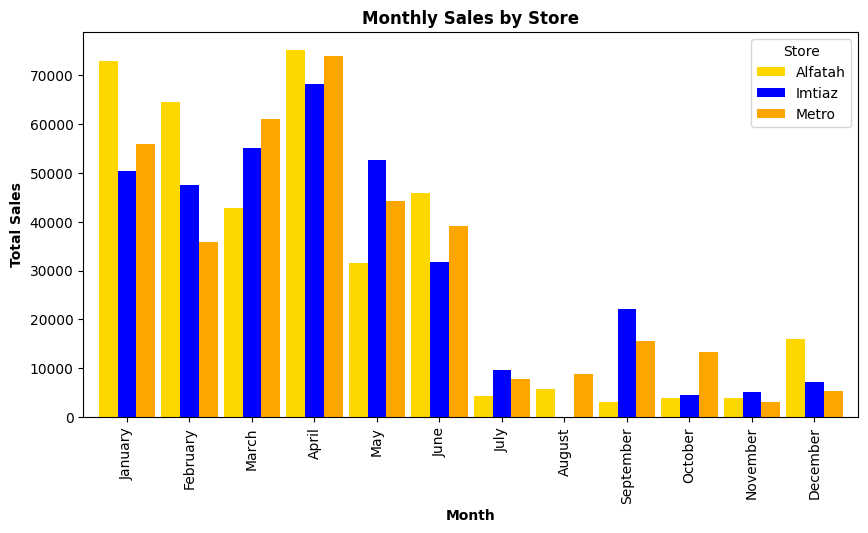

In [ ]:
pivot = df.pivot_table( index='Month', columns='Store', values='Total_Price', aggfunc='sum')
pivot.plot(kind='bar', figsize=(10,5), width=0.9, color=['gold','blue','orange'])
plt.title('Monthly Sales by Store', fontweight= 'bold')
plt.xlabel('Month', fontweight= "bold")
plt.ylabel('Total Sales', fontweight='bold')
plt.show()

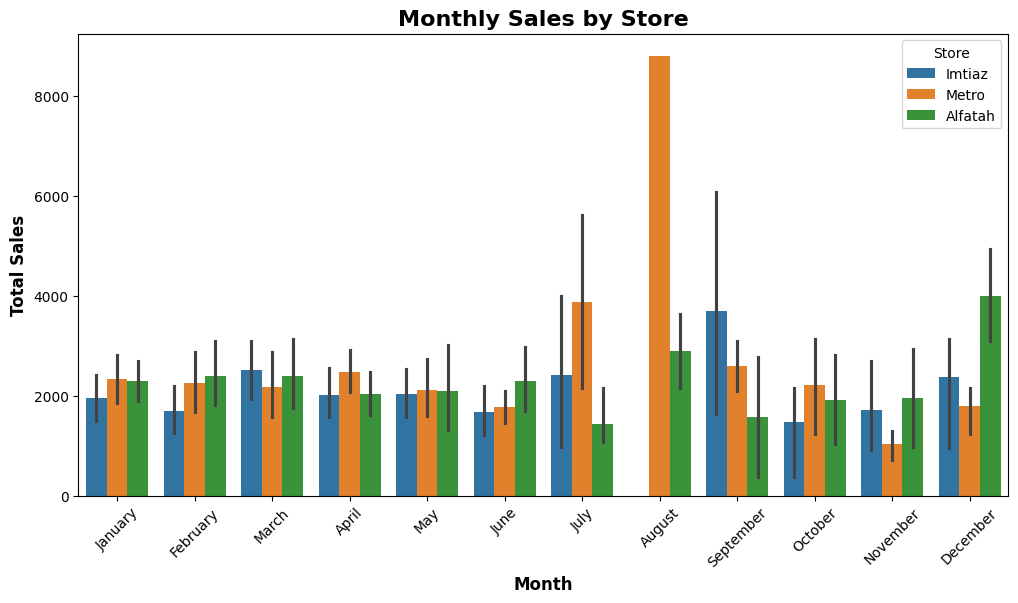

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=df,x='Month',y='Total_Price',hue='Store')

plt.title('Monthly Sales by Store', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.show()

In [ ]:
sales_by_product = (df.groupby(['Month','Store'])['Total_Price'].sum())
sales_by_product

Month      Store  
January    Alfatah    73006.0
           Imtiaz     50507.0
           Metro      55866.0
February   Alfatah    64502.0
           Imtiaz     47547.0
           Metro      35946.0
March      Alfatah    42880.0
           Imtiaz     55054.0
           Metro      61003.0
April      Alfatah    75139.0
           Imtiaz     68299.0
           Metro      73882.0
May        Alfatah    31454.0
           Imtiaz     52692.0
           Metro      44302.0
June       Alfatah    45889.0
           Imtiaz     31694.0
           Metro      39132.0
July       Alfatah     4286.0
           Imtiaz      9639.0
           Metro       7762.0
August     Alfatah     5772.0
           Imtiaz         0.0
           Metro       8800.0
September  Alfatah     3141.0
           Imtiaz     22132.0
           Metro      15501.0
October    Alfatah     3840.0
           Imtiaz      4422.0
           Metro      13250.0
November   Alfatah     3896.0
           Imtiaz      5153.0
           Metro       3086.0
December   Alfatah    15979.0
           Imtiaz      7088.0
           Metro       5384.0
Name: Total_Price, dtype: float64

In [ ]:
sales_by_product

Month      Store  
January    Alfatah    73006.0
           Imtiaz     50507.0
           Metro      55866.0
February   Alfatah    64502.0
           Imtiaz     47547.0
           Metro      35946.0
March      Alfatah    42880.0
           Imtiaz     55054.0
           Metro      61003.0
April      Alfatah    75139.0
           Imtiaz     68299.0
           Metro      73882.0
May        Alfatah    31454.0
           Imtiaz     52692.0
           Metro      44302.0
June       Alfatah    45889.0
           Imtiaz     31694.0
           Metro      39132.0
July       Alfatah     4286.0
           Imtiaz      9639.0
           Metro       7762.0
August     Alfatah     5772.0
           Imtiaz         0.0
           Metro       8800.0
September  Alfatah     3141.0
           Imtiaz     22132.0
           Metro      15501.0
October    Alfatah     3840.0
           Imtiaz      4422.0
           Metro      13250.0
November   Alfatah     3896.0
           Imtiaz      5153.0
           Metro       3086.0
December   Alfatah    15979.0
           Imtiaz      7088.0
           Metro       5384.0
Name: Total_Price, dtype: float64

In [ ]:
df

,Transaction_ID,Date,Store,City,Product,category,Quantity,Unit_Price,Total_Price,Payment_Method,Customer_Type,Month,year
0,1141,2024-05-01,Imtiaz,Islamabad,Chicken,Meat,1.0,537.0,537.0,Online,Member,May,2024
1,1399,2024-11-04,Imtiaz,Islamabad,Oil,Grains,5.0,537.0,2685.0,Online,Regular,November,2024
2,1007,2024-12-04,Imtiaz,Islamabad,Oil,Grains,4.0,785.0,3140.0,Card,Regular,December,2024
3,1335,2024-04-02,Imtiaz,Islamabad,Chicken,Meat,1.0,848.0,848.0,Cash,Regular,April,2024
4,1323,2024-04-02,Metro,Islamabad,Milk,Dairy,1.0,537.0,537.0,Cash,Regular,April,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1072,2024-05-07,Imtiaz,Lahore,Rice,Grains,2.0,310.0,620.0,Card,Member,May,2024
496,1107,2024-02-04,Alfatah,Karachi,Apple,Fruits,2.0,834.0,1668.0,Online,Regular,February,2024
497,1271,2024-06-10,Imtiaz,Karachi,Rice,Grains,6.0,512.0,3072.0,Card,Member,June,2024
498,1436,2024-06-05,Imtiaz,Lahore,Apple,Fruits,6.0,537.0,3222.0,Cash,Regular,June,2024


In [ ]:
payment_sales = df.groupby('Payment_Method')['Total_Price'].sum()

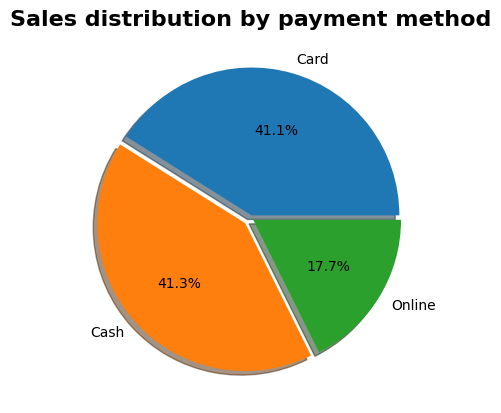

In [ ]:
plt.pie(payment_sales, labels=payment_sales.index,autopct='%1.1f%%', explode=[0.02,0.05,0.02], shadow= True)
plt.title("Sales distribution by payment method", fontweight='bold', fontsize=16)
plt.show()